# Predictive Model Exploration

This notebook explores the results of the player value predictive model. We will analyze:
1. Model Performance (Actual vs Predicted)
2. Feature Importance (What drives value?)
3. Sleepers and Busts (Market inefficiencies)

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Add parent directory to path to import models
sys.path.append(os.path.abspath('..'))

from models.train_value_model import train_and_get_models

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Models and Data

We retrain/load the models directly from the script to get access to the internal state.

In [2]:
models, artifacts, final_df = train_and_get_models()

Loading Silver (Stats) and Gold (Rankings) layers...
Aggregating season stats...

--- Model Training ---


## 2. Actual vs Predicted Analysis

Let's visualize how well our model predicts player value for each position.

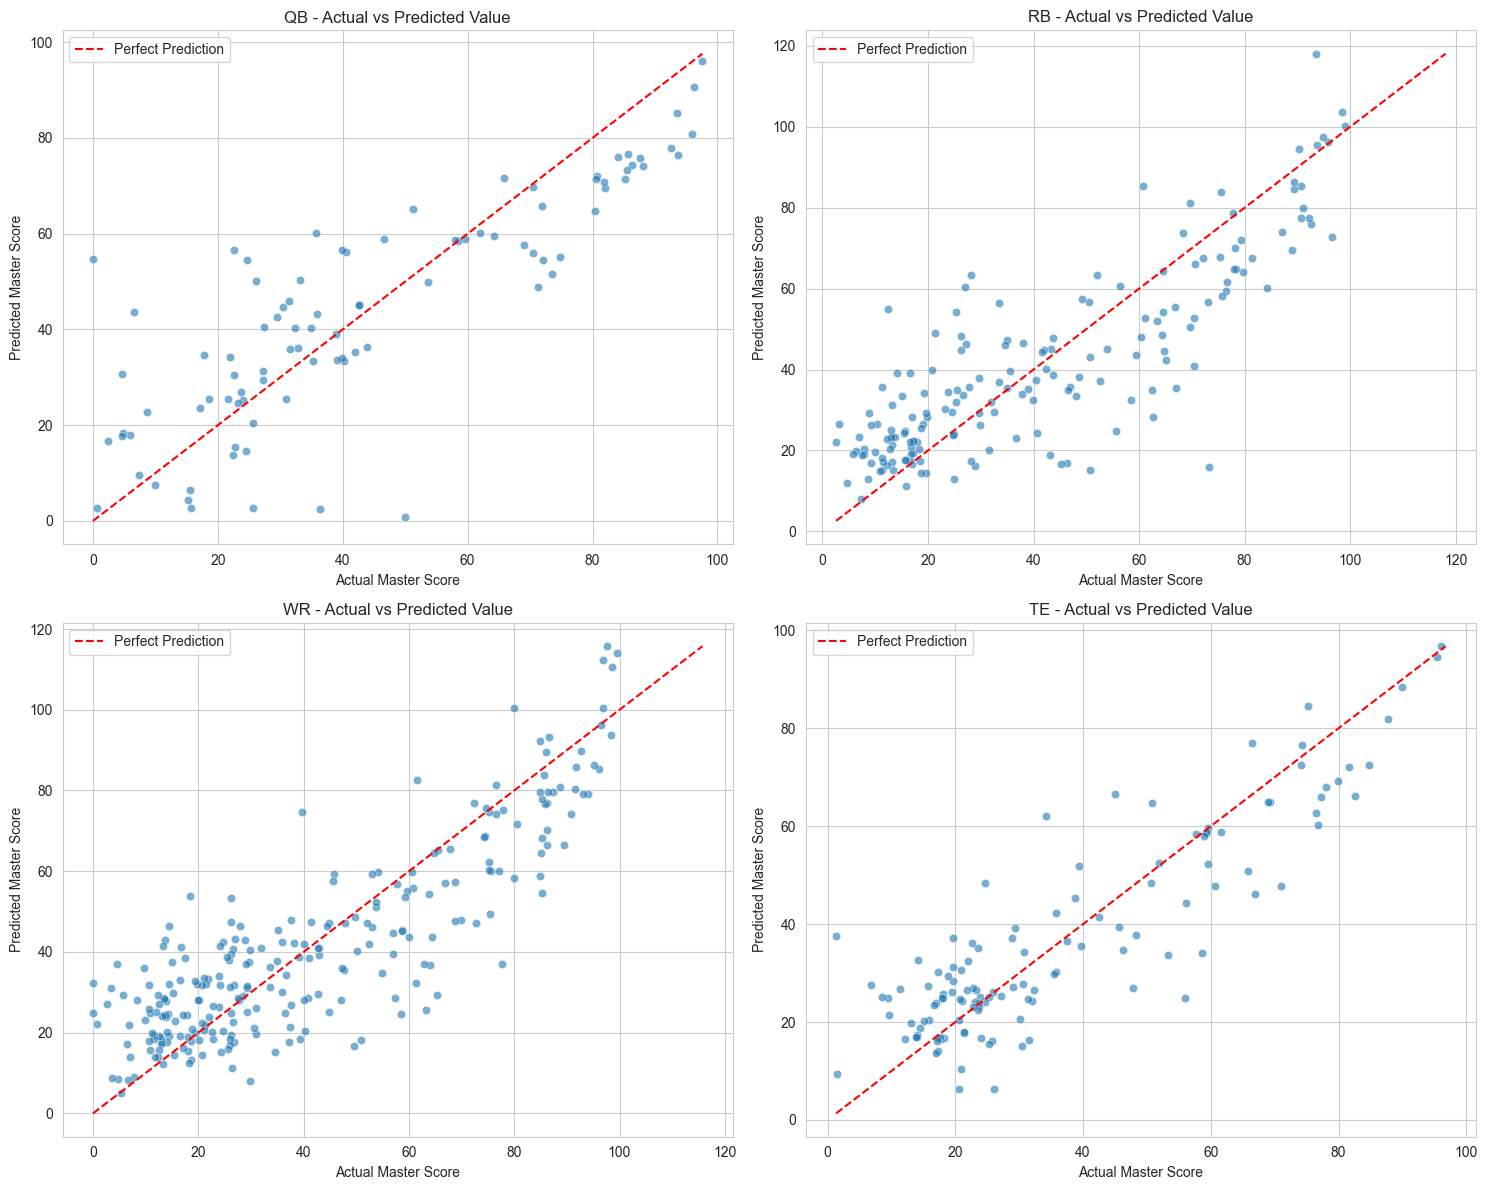

In [3]:
positions = ['QB', 'RB', 'WR', 'TE']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, pos in enumerate(positions):
    if pos not in artifacts:
        continue
        
    data = artifacts[pos]
    y_true = data['y']
    # Predict using the pipeline
    y_pred = models[pos].predict(data['X'])
    
    ax = axes[i]
    sns.scatterplot(x=y_true, y=y_pred, ax=ax, alpha=0.6)
    
    # Ideal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
    
    ax.set_title(f'{pos} - Actual vs Predicted Value')
    ax.set_xlabel('Actual Master Score')
    ax.set_ylabel('Predicted Master Score')
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Feature Importance

Which metrics drive the model's valuation of a player?

C:\Users\solta\AppData\Local\Temp\ipykernel_19000\1526119410.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Coefficient', y='Feature', palette='viridis')


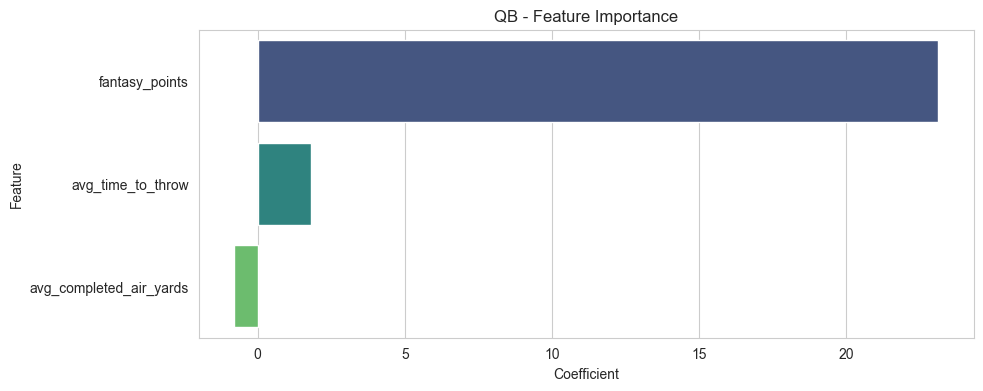

C:\Users\solta\AppData\Local\Temp\ipykernel_19000\1526119410.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Coefficient', y='Feature', palette='viridis')


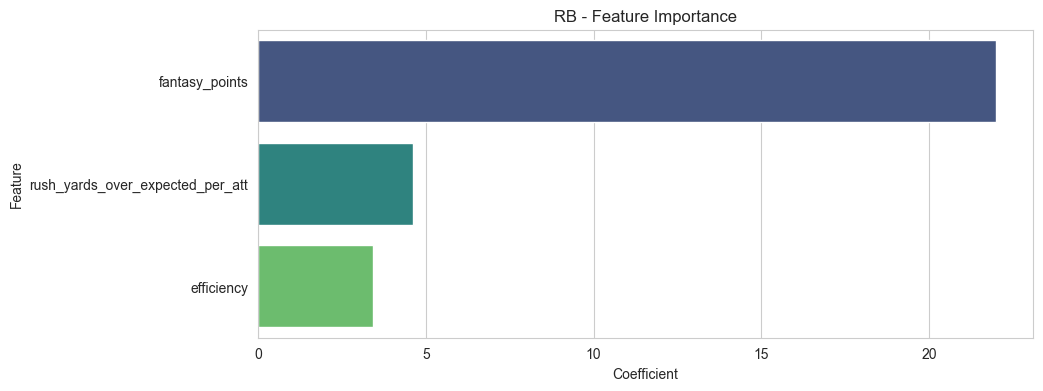

C:\Users\solta\AppData\Local\Temp\ipykernel_19000\1526119410.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Coefficient', y='Feature', palette='viridis')


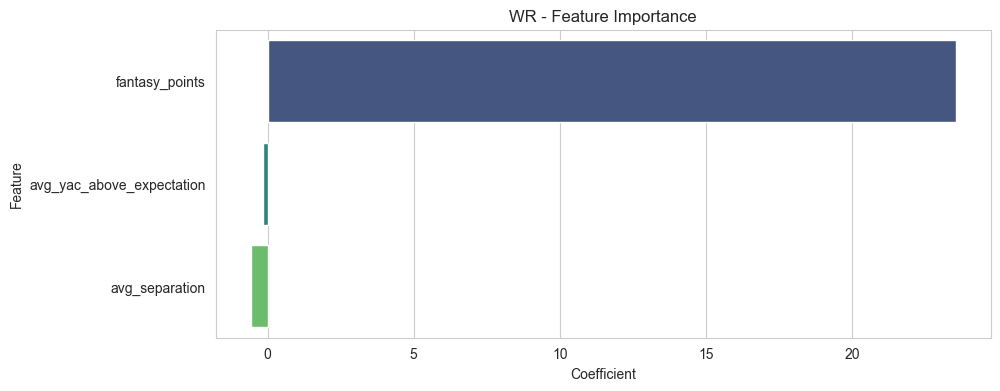

C:\Users\solta\AppData\Local\Temp\ipykernel_19000\1526119410.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Coefficient', y='Feature', palette='viridis')


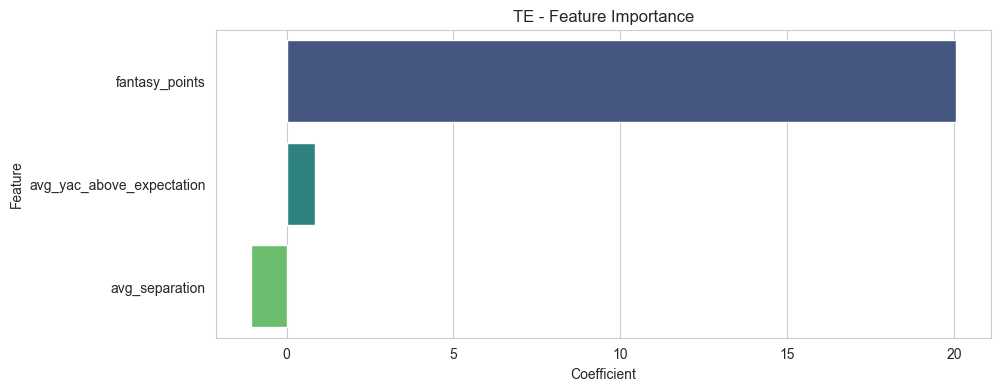

In [4]:
for pos in positions:
    if pos not in models:
        continue
        
    pipe = models[pos]
    features = artifacts[pos]['features']
    coefs = pipe.named_steps['model'].coef_
    
    # Create DF for plotting
    feat_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})
    feat_df = feat_df.sort_values('Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 4))
    sns.barplot(data=feat_df, x='Coefficient', y='Feature', palette='viridis')
    plt.title(f'{pos} - Feature Importance')
    plt.show()

## 4. Top Sleepers (Undervalued)

Players where the model thinks they are better than their ranking.

In [7]:
print("Top 10 Overall Sleepers (High Value Delta):")
print(final_df.sort("value_delta", descending=False).head(30))

Top 10 Overall Sleepers (High Value Delta):
shape: (30, 5)
┌───────────────────┬──────────┬──────────────┬─────────────────┬─────────────┐
│ player_name       ┆ position ┆ actual_score ┆ predicted_score ┆ value_delta │
│ ---               ┆ ---      ┆ ---          ┆ ---             ┆ ---         │
│ str               ┆ str      ┆ f64          ┆ f64             ┆ f64         │
╞═══════════════════╪══════════╪══════════════╪═════════════════╪═════════════╡
│ Kaleb Johnson     ┆ RB       ┆ 73.269193    ┆ 15.915323       ┆ -57.353869  │
│ Jalen Milroe      ┆ QB       ┆ 50.00868     ┆ 0.844841        ┆ -49.163839  │
│ Matthew Golden    ┆ WR       ┆ 77.651425    ┆ 36.929089       ┆ -40.722336  │
│ Kyle Williams     ┆ WR       ┆ 63.240543    ┆ 25.613213       ┆ -37.627329  │
│ Tre Harris        ┆ WR       ┆ 65.345279    ┆ 29.300768       ┆ -36.044511  │
│ …                 ┆ …        ┆ …            ┆ …               ┆ …           │
│ Cedric Tillman    ┆ WR       ┆ 62.933458    ┆ 37.028119    